In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        """ this is to render result instead of cryptic output in Python """
        return f"Value(data={self.data})"

    def __add__(self, operand):
        # overrriding '+' method in python
        out = Value(self.data + operand.data, (self, operand), '+')

        """ plus-op just copies grad result """
        def _backward():
            self.grad += 1.0 * out.grad # * as per chaining rule, += to account for 'a + a' - refer Multivariable case
            operand.grad += 1.0 * out.grad # * as per chaining rule, += to account for 'a + a' - refer Multivariable case
        out._backward = _backward # note we want just set/store the func, but not the result, hence there are no '()'
        
        return out

    def __mul__(self, operand):
        out = Value(self.data * operand.data, (self, operand), '*')

        """ multiply-op just copies another arg multiplied by output result grad, as per chain rule """
        def _backward():
            self.grad += operand.data * out.grad # * as per chaining rule, += to account for 'a + a' - refer Multivariable case
            operand.grad += self.data * out.grad # * as per chaining rule, += to account for 'a + a' - refer Multivariable case
        out._backward = _backward
        
        return out

    """ tanH as an activation(squashing) function. refer: https://en.wikipedia.org/wiki/Hyperbolic_functions#Definitions """
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - out.data ** 2) * out.grad # as per  cheatsheegt in wiki / see below
        out._backward = _backward
        
        return out

    def backward(self):
        topo = []
        
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [3]:
# inputs x
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8813, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
# body on neuron without activation func
n = x1w1x2w2 + b; n.label = 'n'
# draw_dot(n)

# steps from below for convenience
o = n.tanh(); o.label = 'output O'

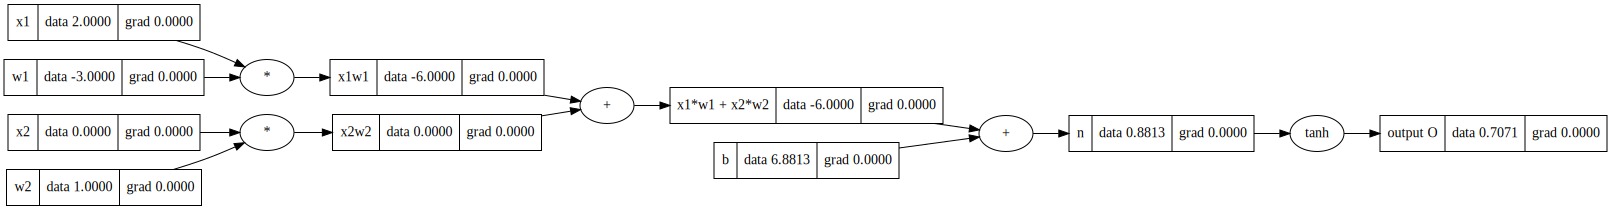

In [26]:
# import draw_dot
# draw_dot.draw_dot(o)

# OR
%run draw_dot.py
draw_dot(o)